# Phase 3: Model Training and Evaluation
## EfficientNetB2 for FER

**Steps:**
1. Load datasets
2. Train EfficientNetB2
3. Cross-dataset evaluation
4. Generate reports

In [1]:
# Install required packages (run once)
import sys
!{sys.executable} -m pip install typing_extensions --upgrade --quiet
!{sys.executable} -m pip install torch torchvision --quiet
!{sys.executable} -m pip install opencv-python==4.8.0.76 scikit-learn scikit-image pillow --quiet
!{sys.executable} -m pip install efficientnet-pytorch --quiet
!{sys.executable} -m pip install facenet-pytorch --quiet
print("✓ All packages installed!")

✓ All packages installed!


In [2]:
import sys
sys.path.append('..')

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from src.utils.config import Config, setup_seed, create_directories
from src.data.dataset_loader import FER2013Dataset, CKPlusDataset, JAFFEDataset, get_transforms
from src.models.efficientnet_model import EfficientNetFER
from src.models.trainer import FERTrainer
from src.evaluation.cross_dataset_eval import CrossDatasetEvaluator
from src.utils.visualization import plot_cross_dataset_performance

config = Config('../config/config.yaml')
setup_seed(config.get('project.random_seed'))
create_directories(config)

device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
print(f'Device: {device}')
%matplotlib inline

Device: mps


## 1. Load Datasets

In [3]:
train_transform = get_transforms(config, is_training=True)
test_transform = get_transforms(config, is_training=False)

# Fix paths - config paths are relative to project root, we're in notebooks/
# FER2013 only has train/test, use test as validation during training
fer_train = FER2013Dataset('../' + config.get('data.fer2013.path'), split='train', transform=train_transform)
fer_test = FER2013Dataset('../' + config.get('data.fer2013.path'), split='test', transform=test_transform)
fer_val = fer_test  # Use test set for validation during training
print(f'FER2013: Train={len(fer_train)}, Val={len(fer_val)}, Test={len(fer_test)}')

try:
    ckplus = CKPlusDataset('../' + config.get('data.ckplus.path'), transform=test_transform)
    print(f'CK+: {len(ckplus)}')
except Exception as e:
    print(f'CK+ not available: {e}')
    ckplus = None

try:
    jaffe = JAFFEDataset('../' + config.get('data.jaffe.path'), transform=test_transform)
    print(f'JAFFE: {len(jaffe)}')
except Exception as e:
    print(f'JAFFE not available: {e}')
    jaffe = None

Loading from: ../data/raw/FER2013/train


Loaded 28709 images from ../data/raw/FER2013/train
Loading from: ../data/raw/FER2013/test


Loaded 7178 images from ../data/raw/FER2013/test
FER2013: Train=28709, Val=7178, Test=7178
Loading from: ../data/raw/CK+48/ck+


Loaded 981 images from CK+
CK+: 981
Loading from: ../data/raw/jaffe/jaffe


Loading JAFFE: 100%|██████████| 213/213 [00:00<00:00, 2160.07it/s]

Loaded 213 images from JAFFE
JAFFE: 213


## 2. Create DataLoaders

In [4]:
batch_size = config.get('model.batch_size')

train_loader = DataLoader(fer_train, batch_size=batch_size, shuffle=True, num_workers=4, pin_memory=True)
val_loader = DataLoader(fer_val, batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True)
test_loader = DataLoader(fer_test, batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True)

print(f'Batch size: {batch_size}')
print(f'Train batches: {len(train_loader)}')

Batch size: 8
Train batches: 3589


## 3. Create Model

In [5]:
model = EfficientNetFER(
    model_name=config.get('model.architecture'),
    num_classes=config.get('emotions.num_classes'),
    pretrained=config.get('model.pretrained'),
    dropout=config.get('model.dropout')
)

params = model.count_parameters()
print(f"Model: {config.get('model.architecture')}")
print(f'Parameters: {params["total"]:,}')
print(f'Size: ~{params["total"] * 4 / 1024 / 1024:.1f} MB')

Loaded pretrained weights for efficientnet-b2
Model: efficientnet-b2
Parameters: 8,425,993
Size: ~32.1 MB


## 4. Setup Trainer

In [6]:
emotions = config.get('emotions.classes')
trainer = FERTrainer(model=model, config=config, device=device, class_names=emotions)

if config.get('model.use_class_weights'):
    class_weights = trainer.calculate_class_weights(train_loader)
    print('Class weights:')
    for e, w in zip(emotions, class_weights):
        print(f'  {e}: {w:.3f}')

/opt/anaconda3/lib/python3.11/site-packages/torch/optim/lr_scheduler.py:28: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn("The verbose parameter is deprecated. Please use get_last_lr() "


Class weights:
  angry: 1.027
  disgust: 5.000
  fear: 1.001
  happy: 0.568
  sad: 0.849
  surprise: 1.293
  neutral: 0.826


## 5. Train Model



In [7]:
# ============================================
# CPU OPTIMIZATION: Use 10% of data (STRATIFIED)
# ============================================

print("="*60)
print("REDUCING DATASET FOR CPU TRAINING (STRATIFIED)")
print("="*60)

# Use 20% of data with stratified sampling to ensure all classes present
reduction_factor = 5

# Get all labels to do stratified sampling
import numpy as np
from collections import defaultdict

# Collect indices by class
def get_stratified_indices(dataset, reduction_factor):
    """Get stratified indices ensuring all classes are represented"""
    indices_by_class = defaultdict(list)
    
    # Group indices by label
    for idx in range(len(dataset)):
        try:
            label = dataset[idx][1]  # Assuming (image, label) tuple
            indices_by_class[label].append(idx)
        except:
            # If dataset doesn't support indexing, fall back to sequential
            return list(range(len(dataset) // reduction_factor))
    
    # Sample from each class
    sampled_indices = []
    for label, indices in indices_by_class.items():
        sample_size = max(1, len(indices) // reduction_factor)  # At least 1 per class
        sampled_indices.extend(indices[:sample_size])
    
    return sorted(sampled_indices)

# Get stratified indices
train_indices = get_stratified_indices(fer_train, reduction_factor)
val_indices = get_stratified_indices(fer_val, reduction_factor)

original_train_size = len(fer_train)
original_val_size = len(fer_val)

# Create subsets with stratified indices
fer_train_subset = torch.utils.data.Subset(fer_train, train_indices)
fer_val_subset = torch.utils.data.Subset(fer_val, val_indices)

print(f"Training: {original_train_size} → {len(fer_train_subset)} samples (stratified)")
print(f"Validation: {original_val_size} → {len(fer_val_subset)} samples (stratified)")

# Recreate dataloaders with CPU-optimized settings
from torch.utils.data import DataLoader

train_loader = DataLoader(
    fer_train_subset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0,
    pin_memory=False
)

val_loader = DataLoader(
    fer_val_subset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0,
    pin_memory=False
)

print(f"Batches per epoch: {len(train_loader)}")
print("="*60)

REDUCING DATASET FOR CPU TRAINING (STRATIFIED)
Training: 28709 → 5741 samples (stratified)
Validation: 7178 → 1432 samples (stratified)
Batches per epoch: 718


In [8]:
num_epochs = config.get('model.epochs')
save_dir = '../models/checkpoints'

print(f'Training for {num_epochs} epochs...')

metrics_tracker = trainer.train(
    train_loader=train_loader,
    val_loader=val_loader,
    num_epochs=num_epochs,
    save_dir=save_dir
)

print('✓ Training complete!')

Training for 10 epochs...
Starting Training
Device: mps
Epochs: 10
Training samples: 5741
Validation samples: 1432


Epoch 1 [Val]: 100%|██████████| 179/179 [00:19<00:00,  9.13it/s, loss=1.75]



Epoch 1/10 - 510.6s
  Train Loss: 1.6448 | Train Acc: 0.4079
  Val Loss:   1.7464 | Val Acc:   0.3973
  LR: 0.001000
  ✓ New best model saved! (Val Acc: 0.3973)
------------------------------------------------------------


Epoch 2 [Val]: 100%|██████████| 179/179 [00:19<00:00,  9.01it/s, loss=1.49]



Epoch 2/10 - 512.9s
  Train Loss: 1.5103 | Train Acc: 0.4731
  Val Loss:   1.4945 | Val Acc:   0.4693
  LR: 0.001000
  ✓ New best model saved! (Val Acc: 0.4693)
------------------------------------------------------------


...


Epoch 8/10 - 735.2s
  Train Loss: 1.3795 | Train Acc: 0.5503
  Val Loss:   1.3870 | Val Acc:   0.5440
  LR: 0.001000
  ✓ New best model saved! (Val Acc: 0.5440)
------------------------------------------------------------


Epoch 9 [Val]: 100%|██████████| 179/179 [00:22<00:00,  7.90it/s, loss=1.37]



Epoch 9/10 - 559.0s
  Train Loss: 1.3659 | Train Acc: 0.5560
  Val Loss:   1.3675 | Val Acc:   0.5440
  LR: 0.001000
------------------------------------------------------------


Epoch 10 [Val]: 100%|██████████| 179/179 [00:22<00:00,  8.12it/s, loss=1.45]



Epoch 10/10 - 537.4s
  Train Loss: 1.3446 | Train Acc: 0.5607
  Val Loss:   1.4465 | Val Acc:   0.5056
  LR: 0.001000
------------------------------------------------------------

Training Complete!
Best validation accuracy: 0.5440 (Epoch 8)
✓ Training complete!


## 6. Plot Training History

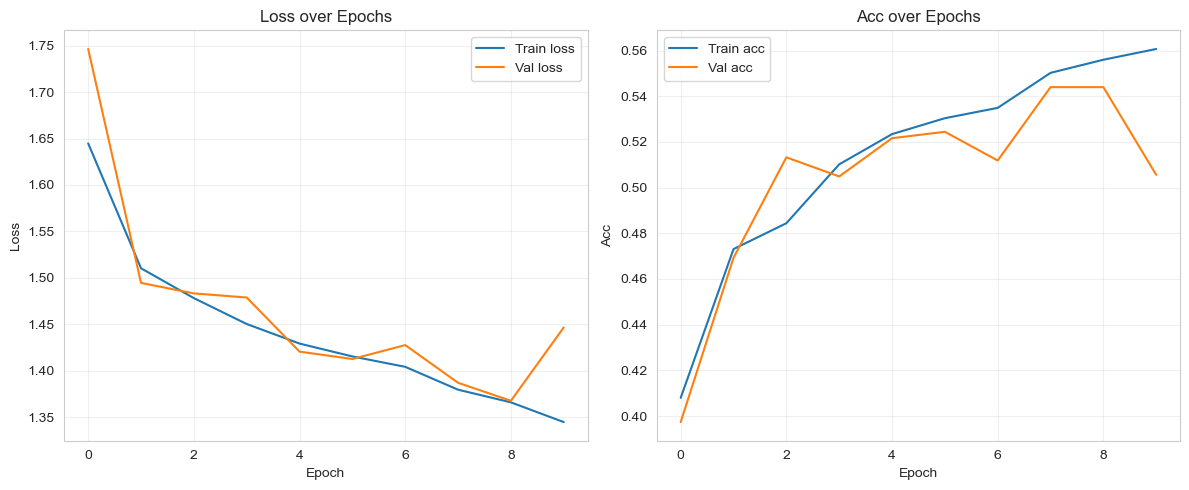

Best: 0.5440 at epoch 8


In [9]:
fig = metrics_tracker.plot_history(metrics=['loss', 'acc'], 
    save_path='../outputs/figures/training_history.png')
plt.show()

metrics_tracker.save('../outputs/logs/training_metrics.npy')

best_epoch, best_acc = metrics_tracker.get_best_epoch('val_acc', mode='max')
print(f'Best: {best_acc:.4f} at epoch {best_epoch + 1}')

## 7. Evaluate on Test Set

In [10]:
checkpoint = torch.load(Path(save_dir) / 'best_model.pth', map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])

test_metrics = trainer.validate(test_loader, epoch=0)

print('FER2013 Test Results:')
print(f"  Accuracy: {test_metrics['accuracy']:.4f}")
print(f"  F1: {test_metrics['f1_macro']:.4f}")

Epoch 0 [Val]: 100%|██████████| 898/898 [02:26<00:00,  6.13it/s, loss=1.38]


FER2013 Test Results:
  Accuracy: 0.5428
  F1: 0.4079


## 8. Cross-Dataset Evaluation


Evaluating on FER2013_Test...


Evaluating FER2013_Test: 100%|██████████| 898/898 [02:04<00:00,  7.20it/s]



FER2013_Test Results:
  Accuracy:  0.5428
  F1 (macro): 0.4079
  Precision: 0.4392
  Recall:    0.4528

Evaluating on CK+...


Evaluating CK+: 100%|██████████| 123/123 [00:37<00:00,  3.27it/s]
/Users/nyanwaiphyo/Signature Project/fer-project/notebooks/../src/utils/metrics.py:94: RuntimeWarning: invalid value encountered in divide
  cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]



CK+ Results:
  Accuracy:  0.5902
  F1 (macro): 0.3791
  Precision: 0.4021
  Recall:    0.4326

Evaluating on JAFFE...


...


FER2013_Test Results:
  Accuracy:  0.5428
  F1 (macro): 0.4079
  Precision: 0.4392
  Recall:    0.4528

Evaluating on CK+...


Evaluating CK+: 100%|██████████| 123/123 [00:37<00:00,  3.27it/s]



CK+ Results:
  Accuracy:  0.5902
  F1 (macro): 0.3791
  Precision: 0.4021
  Recall:    0.4326

Evaluating on JAFFE...


Evaluating JAFFE: 100%|██████████| 27/27 [00:27<00:00,  1.01s/it]



JAFFE Results:
  Accuracy:  0.3380
  F1 (macro): 0.2317
  Precision: 0.1960
  Recall:    0.3381

Per-Class Performance Comparison
Emotion        FER2013_Test   CK+            JAFFE          
--------------------------------------------------------------------------------
angry          0.4625         0.4807         0.0000         
disgust        0.0000         0.0000         0.0000         
fear           0.0357         0.0000         0.0000         
happy          0.7919         0.9324         0.6078         
sad            0.3495         0.3148         0.0000         
surprise       0.6772         0.9258         0.7241         
neutral        0.5383         0.0000         0.2899         


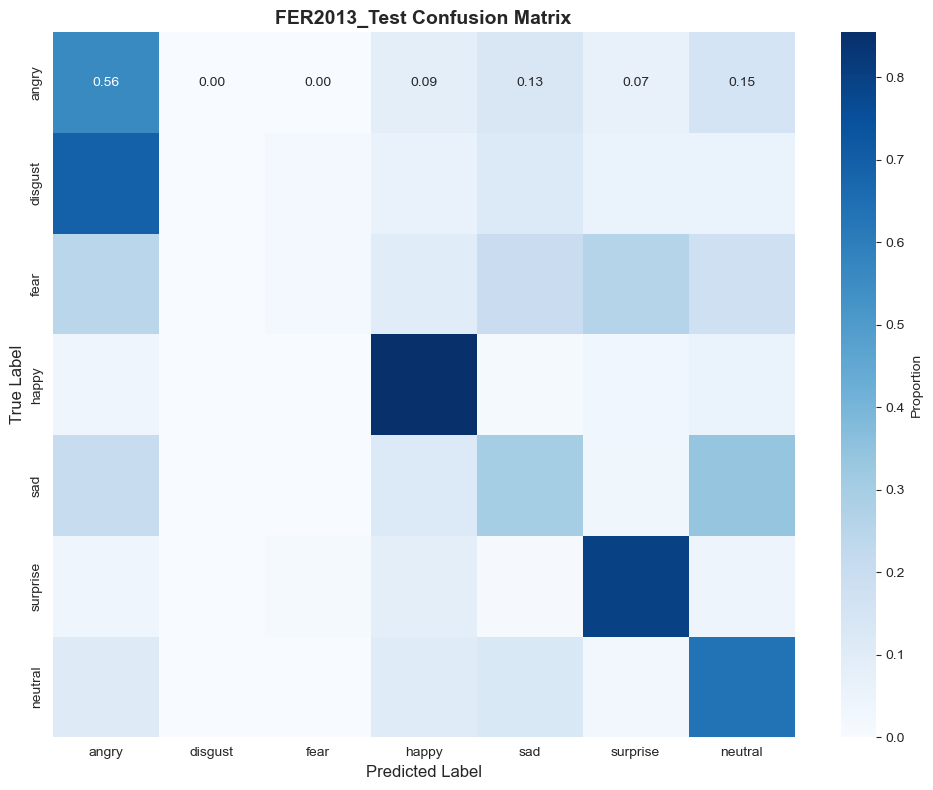

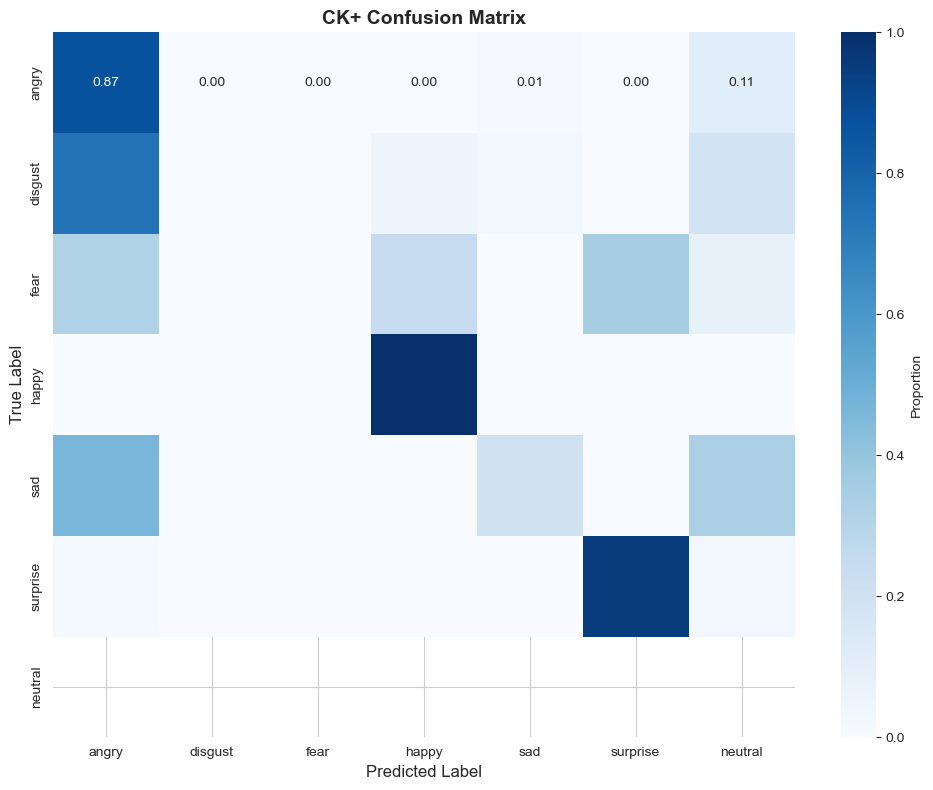

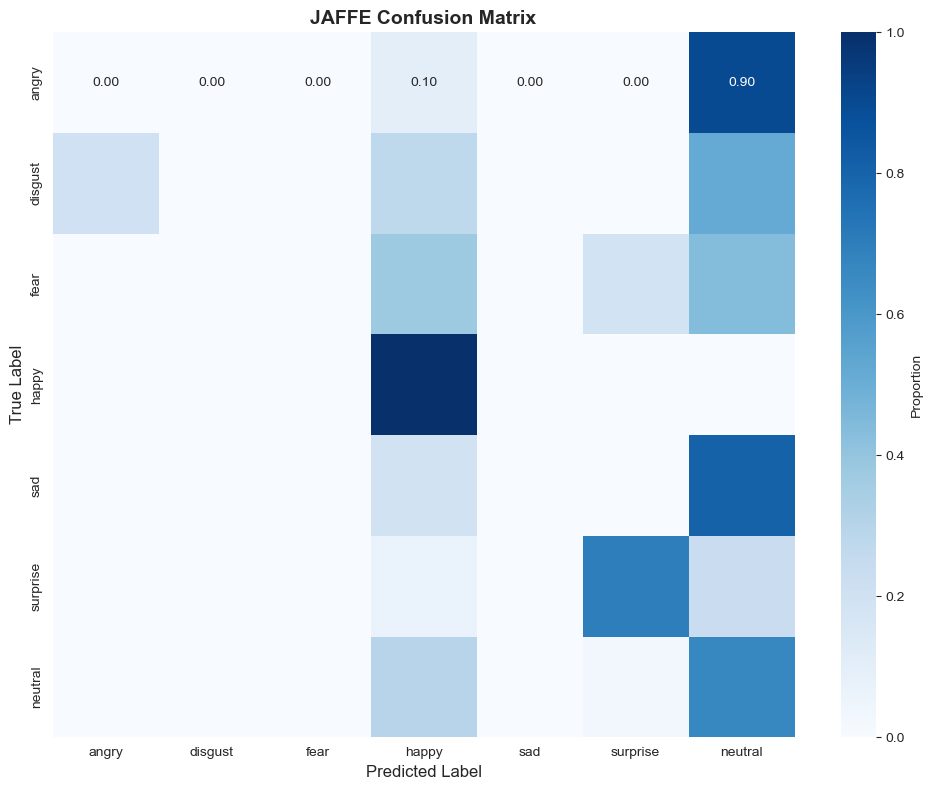

In [11]:
evaluator = CrossDatasetEvaluator(model=model, class_names=emotions, device=device)

eval_datasets = {'FER2013_Test': test_loader}
if ckplus:
    eval_datasets['CK+'] = DataLoader(ckplus, batch_size=batch_size, shuffle=False, num_workers=4)
if jaffe:
    eval_datasets['JAFFE'] = DataLoader(jaffe, batch_size=batch_size, shuffle=False, num_workers=4)

results, cms = evaluator.evaluate_all_datasets(eval_datasets, save_dir='../outputs/figures')
per_class = evaluator.compare_per_class_performance(eval_datasets)

## 9. Visualize Results

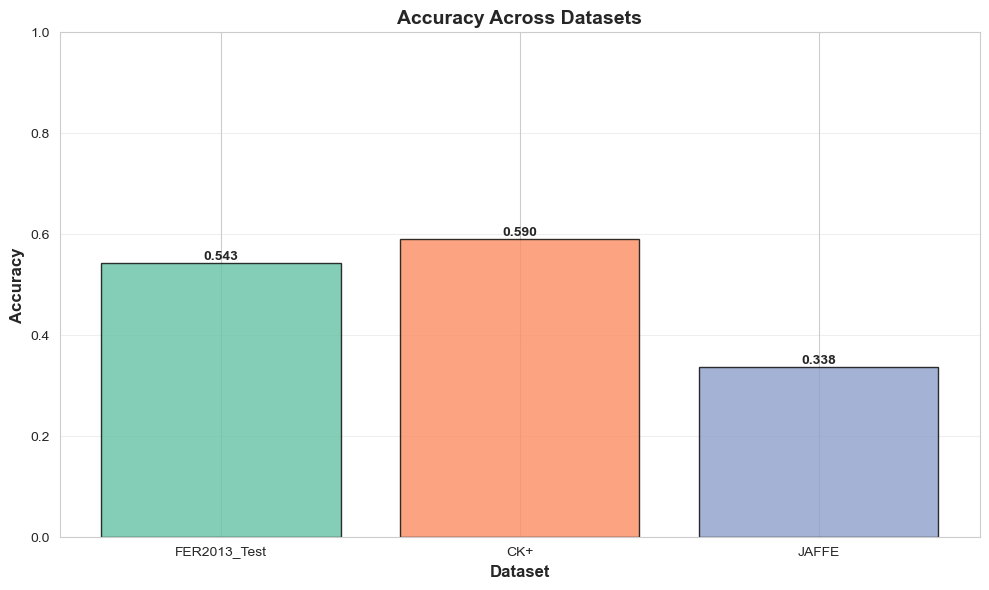

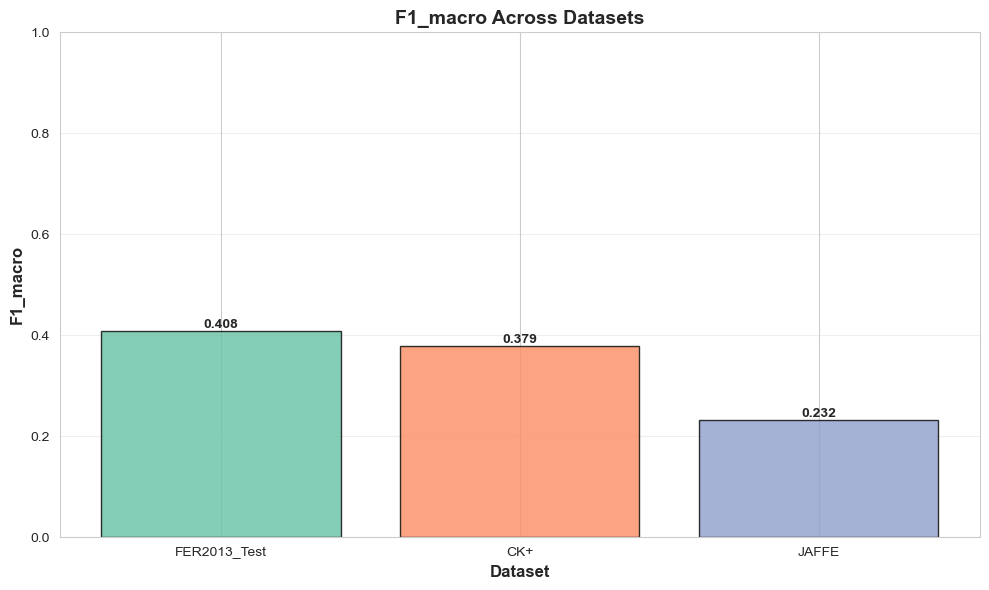


✓ Phase 3 Complete!
✓ Check outputs/ for all results


In [ ]:
plot_cross_dataset_performance(results, metric='accuracy', 
    save_path='../outputs/figures/cross_dataset_accuracy.png')
plt.show()

plot_cross_dataset_performance(results, metric='f1_macro',
    save_path='../outputs/figures/cross_dataset_f1.png')
plt.show()

print('\n✓ Phase 3 Complete!')
print('✓ Check outputs/ for all results')